In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("wordle_lab_solutions.ipynb")

# Wordle!

#### Authors:
v1.0 (Fall 2022): Andy Dong

v1.1 (Spring 2025): Lance Mathias

v1.2 (Fall 2026): Rex Ouyang

> **STAFF SOLUTIONS — DO NOT DISTRIBUTE.** This notebook has the same cells and otter tests as `wordle_lab.ipynb`, with every task implemented and a worked answer for every written question. The numbers quoted in the answers come from running the notebook top to bottom with the default seed.

## Setup
This lab runs on JupyterHub or on your own machine. The first time you run it, the notebook builds a lookup table of Wordle color patterns (about 30 MB, usually under a minute) and caches it in the `checkpoint/` folder, so later runs start right away.

**How this lab is organized**
- Sections marked **(Read Only)** contain provided code and explanations. Read them and run their cells; the provided code cells are locked and you don't need to change them.
- **Tasks** are functions for you to implement wherever you see `...`. Each task is followed by a `grader.check(...)` cell that runs its tests.
- **Written Questions** are answered in the accompanying Gradescope assignment, along with any plots they ask for.
- The **Wordle Bot** section at the end is optional and not graded.

You don't need to know any information theory for this lab. Everything is built from conditional probability and expectation.

## Introduction

In the game of [Wordle](https://www.nytimes.com/games/wordle/index.html), your goal is to deduce a 5-letter secret word that the game has generated using as few guesses as possible. After each guess, the game will tell you for each letter in your guess, whether the letter is

-  in the secret word and in the right spot (indicated by green),
-  in the secret word but in the wrong spot (indicated by yellow),
-  or not in the secret word (indicated by gray).

Take a look at the example game below where the secret word is "scald".

<div>
<img src="examples/ex-0.png" width="500"/>
</div>

Suppose we want to write a program that solves the game in as few guesses as possible. In this lab, you will build a greedy solver using conditional probability: after every guess, work out which words the secret could still be, then pick the next guess that is expected to narrow them down the most. It's recommended that you play a game of Wordle first to get familiar with the rules.

In [2]:
# If modules have not been installed yet:

%pip install -r requirements.txt

# Restart kernel afterwards, if needed

Note: you may need to restart the kernel to use updated packages.


In [3]:
import math
import os
import random
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tqdm import tqdm

rng_seed = 0
random.seed(rng_seed)  # makes the random samples in this notebook reproducible

## Modeling the Game

Here's some setup and simplifying assumptions about the game. First, we have obtained the list of 2315 words that can be chosen as the secret word. The secret word $X$ is modeled to be a random variable that has uniform distribution over these possible words. Second, your guess cannot be any arbitrary combination of 5 letters but needs to be from a list of 12972 valid guesses (which, of course, contains the 2315 possible secret words). Third, any revealed hints don't need to be used in subsequent guesses. With these, let's dive in!

Run the following cell to read in the list of possible secret words and the list of allowed guesses.

In [4]:
with open('data/possible_words.txt') as file:
    possible_words = [line.rstrip() for line in file]
with open('data/allowed_guesses.txt') as file:
    allowed_guesses = [line.rstrip() for line in file]

print('Number of possible_words:', len(possible_words))
print('Number of allowed_guesses:', len(allowed_guesses))

Number of possible_words: 2315
Number of allowed_guesses: 12972


Let's print out some of these words to take a look. `possible_words` consists of words used more frequently in the English language while `allowed_guesses` contains some words that we don't see in day-to-day life.

In [5]:
print('Some possible secret words:')
print(*random.sample(possible_words, 20), '\n')
print('Some allowed guesses:')
print(*random.sample(allowed_guesses, 20))

Some possible secret words:
rerun shelf beach joust track swoon scaly mocha stuck prick grail timid dolly lorry donut chute impel valet drool mower 

Some allowed guesses:
busti upped blude teils iodic omrah ricer cabby khaki morat houff sient soyuz elsin rehab otter musha prese gayly betty


## Implementing the Game Logic (Read Only)

We then implement the logic of the game by first computing the pattern that we will see for a given pair of guess and secret word. The function `compute_pattern` takes in a guess and a secret word, and returns an integer tuple of length 5 that represents the color pattern, where an entry of 2 represents green in the corresponding position, 1 represents yellow, and 0 represents gray.

There's an edge case that we will need to consider, which is when the guess and/or the secret word contains multiple of the same letter. The rule here is that green (match in the correct spot) always has the highest priority, yellow (match in the wrong spot) prioritizes letters in earlier positions of your guess, and each letter in the secret word can only correspond to one letter in the guess. Take a look at the examples below.

- If the secret word is "abide" and the guess is "three", the pattern would be (0, 0, 0, 0, 2). Position 5 is an exact match so it has the highest priority to be green. Position 4 is indeed a match in the wrong spot, but since the "e" in "abide" is already taken, it cannot match to that same "e" again.

![title](examples/ex-1.png)

- If the secret word is "abide" and the guess is "drama", the pattern would be (1, 0, 1, 0, 0). Position 3 is a yellow match that has priority over the potential yellow match at position 5.

![title](examples/ex-2.png)

In [6]:
@lru_cache(maxsize=None)
def compute_pattern(guess, answer):
    # Returns a length 5 tuple

    pattern = [0, 0, 0, 0, 0]
    taken = [False, False, False, False, False]

    # Green pass
    for i in range(5):
        if guess[i] == answer[i]:
            # If it's an exact match, color it green, and mark it as taken
            # so that the yellow pass doesn't match to it again
            pattern[i] = 2
            taken[i] = True

    # Yellow pass
    for i in range(5):
        if pattern[i] == 2:
            # If a spot is already colored green, we skip it
            continue
        query = guess[i]
        for j in range(5):
            if query == answer[j] and taken[j] is False:
                # If there is a misplaced match that is not taken by the
                # green pass or a previous yellow pass, we color it yellow
                # and mark it as taken
                pattern[i] = 1
                taken[j] = True
                break

    return tuple(pattern)

## Pattern Lookup Table (Read Only)

The solver needs the color pattern for millions of (guess, secret word) pairs, so we compute all of them once and store them in a table. Each pattern is encoded as an integer in $[0, 243)$ by reading it as a base-3 number, e.g. (2, 1, 0, 0, 2) $\to$ 191, and the table is a matrix with one row per allowed guess and one column per possible secret word (12972 $\times$ 2315, about 30 MB).

**In the rest of the lab, use `pattern_table[guess][answer]` instead of `compute_pattern(guess, answer)`.** It returns the same tuple but is much faster. It also works for words outside the precomputed lists by falling back to `compute_pattern`. You don't need to understand how the table is built.

In [7]:
PATTERN_POWERS = 3 ** np.arange(4, -1, -1)  # [81, 27, 9, 3, 1]

def pattern_to_code(pattern):
    # length-5 tuple -> integer in [0, 243), e.g. (2, 1, 0, 0, 2) -> 191
    return int(np.dot(pattern, PATTERN_POWERS))

@lru_cache(maxsize=None)
def code_to_pattern(code):
    # integer in [0, 243) -> length-5 tuple
    digits = []
    for _ in range(5):
        digits.append(code % 3)
        code //= 3
    return tuple(reversed(digits))

def build_pattern_matrix(guesses, answers, chunk_size=512):
    # Vectorized equivalent of compute_pattern over all (guess, answer) pairs.
    # Returns a (len(guesses), len(answers)) uint8 matrix of base-3 pattern codes.
    g = np.array([[ord(c) - ord('a') for c in w] for w in guesses], dtype=np.uint8)
    a = np.array([[ord(c) - ord('a') for c in w] for w in answers], dtype=np.uint8)
    matrix = np.zeros((len(guesses), len(answers)), dtype=np.uint8)

    for start in tqdm(range(0, len(guesses), chunk_size)):
        gc = g[start:start + chunk_size]
        # eq[i, j, p, q]: does letter p of guess i equal letter q of answer j?
        eq = gc[:, None, :, None] == a[None, :, None, :]
        colors = np.zeros(eq.shape[:3], dtype=np.uint8)

        # Green pass: exact matches take the answer letter out of play
        for p in range(5):
            green = eq[:, :, p, p].copy()
            colors[:, :, p][green] = 2
            eq[:, :, :, p] &= ~green[:, :, None]

        # Yellow pass: earlier guess positions have priority, and each answer
        # letter can only be matched once
        for p in range(5):
            for q in range(5):
                match = eq[:, :, p, q] & (colors[:, :, p] == 0)
                colors[:, :, p][match] = 1
                eq[:, :, :, q] &= ~match[:, :, None]

        matrix[start:start + chunk_size] = colors @ PATTERN_POWERS

    return matrix

pattern_matrix_path = os.path.join('checkpoint', 'pattern_matrix.npy')
expected_shape = (len(allowed_guesses), len(possible_words))

pattern_matrix = None
if os.path.exists(pattern_matrix_path):
    pattern_matrix = np.load(pattern_matrix_path)
if pattern_matrix is None or pattern_matrix.shape != expected_shape:
    # build (or rebuild, if the word lists changed) and cache the table
    pattern_matrix = build_pattern_matrix(allowed_guesses, possible_words)
    os.makedirs('checkpoint', exist_ok=True)
    np.save(pattern_matrix_path, pattern_matrix)

guess_index = {w: i for i, w in enumerate(allowed_guesses)}
answer_index = {w: i for i, w in enumerate(possible_words)}

def get_pattern(guess, answer):
    # Fast table lookup; falls back to computing directly for words outside
    # the precomputed lists
    gi, ai = guess_index.get(guess), answer_index.get(answer)
    if gi is None or ai is None:
        return compute_pattern(guess, answer)
    return code_to_pattern(int(pattern_matrix[gi, ai]))

class _PatternTable:
    # pattern_table[guess][answer] lookups on top of the numpy matrix
    class _Row:
        def __init__(self, guess):
            self.guess = guess
        def __getitem__(self, answer):
            return get_pattern(self.guess, answer)
    def __getitem__(self, guess):
        return self._Row(guess)

pattern_table = _PatternTable()

# Sanity check: the table must agree with compute_pattern
_rng = random.Random(rng_seed)
for _ in range(2000):
    _g, _a = _rng.choice(allowed_guesses), _rng.choice(possible_words)
    assert pattern_table[_g][_a] == compute_pattern(_g, _a)
print('Pattern table ready:', pattern_matrix.shape, '- matches compute_pattern on 2000 random pairs')

100%|██████████| 26/26 [00:10<00:00,  2.57it/s]

Pattern table ready: (12972, 2315) - matches compute_pattern on 2000 random pairs


## Guess Strategy

We use the term *alphabet* of a random variable to mean the set of values it takes with positive probability, i.e. its support (not to be confused with the English alphabet). For example, the alphabet of $X$ is the set of 2315 possible secret words.

Let $Y_i$ be the color pattern we observe after our $i$-th guess. Fix a time index $t$ and suppose we have already observed $Y_1 = y_1, \ldots, Y_{t-1} = y_{t-1}$. Everything we know about the secret word at that point is captured by the conditional distribution of $X$ given these observations. Let $X_t$ be a random variable with that distribution, and let $\mathcal{A}_t$ be its alphabet. At $t = 1$ nothing has been observed yet, so $X_1 = X$ and $\mathcal{A}_1$ is all 2315 possible words.

If we guess the word $k$ at time $t$, the pattern we will see is $Y_{t,k} = f_k(X_t)$, where $f_k(x)$ = `compute_pattern(k, x)`. Note that the index $k$ is a word we guess, and that $Y_{t,k}$ is a *deterministic* function of the secret word: all of its randomness comes from not knowing $X_t$.

<!-- BEGIN QUESTION -->

**Written Question 1:** Suppose $X_t$ is uniform over its alphabet $\mathcal{A}_t$. We guess $k$ and observe $Y_{t,k} = y$.

1. Use Bayes' rule to show that, conditioned on $Y_{t,k} = y$, the secret word is uniform over $\mathcal{A}_{t+1} = \{x \in \mathcal{A}_t : f_k(x) = y\}$.
2. Conclude that $X_t$ is uniform over its alphabet at every time step $t$.
3. Suppose instead that the secret word were *not* uniform to begin with (e.g. common words were more likely). Would $X_t$ still be uniform over its alphabet? What can you say about its distribution instead?

**Solution:**

1. Fix $x \in \mathcal{A}_t$. Since $Y_{t,k} = f_k(X_t)$ is deterministic given $X_t$, $P(Y_{t,k} = y \mid X_t = x) = \mathbb{1}\{f_k(x) = y\}$. With the uniform prior $P(X_t = x) = 1/|\mathcal{A}_t|$,
$$P(Y_{t,k} = y) = \sum_{x' \in \mathcal{A}_t} \frac{\mathbb{1}\{f_k(x') = y\}}{|\mathcal{A}_t|} = \frac{|\mathcal{A}_{t+1}|}{|\mathcal{A}_t|},$$
so by Bayes' rule
$$P(X_t = x \mid Y_{t,k} = y) = \frac{\mathbb{1}\{f_k(x) = y\} \cdot \frac{1}{|\mathcal{A}_t|}}{|\mathcal{A}_{t+1}| / |\mathcal{A}_t|} = \frac{\mathbb{1}\{x \in \mathcal{A}_{t+1}\}}{|\mathcal{A}_{t+1}|},$$
which is the uniform distribution on $\mathcal{A}_{t+1}$.

2. Induction on $t$. $X_1 = X$ is uniform on $\mathcal{A}_1$ by assumption. If $X_t$ is uniform on $\mathcal{A}_t$, then $X_{t+1}$ is $X_t$ further conditioned on $Y_{t,k} = y_t$ (conditioning on $Y_1, \ldots, Y_t$ one observation at a time is the same as conditioning on all of them at once), which is uniform on $\mathcal{A}_{t+1}$ by part 1.

3. No. The same computation gives $P(X = x \mid \text{observations}) = \dfrac{P(X = x)\,\mathbb{1}\{x \text{ consistent}\}}{\sum_{x' \text{ consistent}} P(X = x')}$: the prior restricted to the consistent words and renormalized. The alphabet still shrinks to exactly the consistent words, and the *ratios* of probabilities between surviving words are unchanged, but the posterior is no longer uniform.

<!-- END QUESTION -->

In other words, each guess simply *narrows down* the alphabet: we keep exactly the words that are consistent with the pattern we saw, and they all remain equally likely.

**Task 1:** Implement `filter_alphabet`, which takes in the current alphabet (a list of words), the word we guessed, and the color pattern we observed, and returns a list of the words in the alphabet that are consistent with the observation. This is the alphabet $\mathcal{A}_{t+1}$ from Written Question 1. For example, `filter_alphabet(['shape', 'shake', 'shame'], 'shake', (2, 2, 2, 0, 2))` should return `['shape', 'shame']` (in any order).

In [8]:
def filter_alphabet(alphabet, guess, color_pattern):
    # Returns a list of the words in `alphabet` that would have produced
    # `color_pattern` if they were the secret word
    color_pattern = tuple(color_pattern)
    return [word for word in alphabet if pattern_table[guess][word] == color_pattern]

In [9]:
grader.check("filter_alphabet")

filter_alphabet results: All test cases passed!

## Choosing a Guess

Before we make guess $k$, the pattern $Y_{t,k}$ is random. Guessing $k$ splits the alphabet $\mathcal{A}_t$ into groups of words that share the same pattern, and after the guess we are left with exactly one of those groups. A good guess splits the alphabet into many small groups; a bad guess leaves most of the words together in one big group.

**Task 2:** Implement `divide_alphabet`, which takes in a guess and the current alphabet and splits the alphabet into these groups. Namely, it returns a dictionary that maps each possible color pattern to the list of secret words such that `pattern_table[guess][secret_word]` is that color pattern. For example, if `guess` is "shake" and `alphabet` is {shape, shake, shame}, then the function should return the mapping (2,2,2,2,2)$\to${shake}, (2,2,2,0,2)$\to${shape, shame}.

In [10]:
def divide_alphabet(guess, alphabet):
    pattern_to_subgroup = {}
    for word in alphabet:
        pattern = pattern_table[guess][word]
        pattern_to_subgroup.setdefault(pattern, []).append(word)
    return pattern_to_subgroup

In [11]:
grader.check("divide_alphabet")

divide_alphabet results: All test cases passed!

**Task 3:** Since $X_t$ is uniform over $\mathcal{A}_t$, the probability of observing each pattern is proportional to the size of its group: $P(Y_{t,k} = y) = n_y / N$, where $N = |\mathcal{A}_t|$ and $n_y$ is the number of words in the group for pattern $y$.

Implement `prob_dist`, which takes in the output of `divide_alphabet` and returns the probability distribution over the set of possible patterns. For the same example above, this function would take in the mapping (2,2,2,2,2)$\to${shake}, (2,2,2,0,2)$\to${shape, shame} and return $\left[\frac{1}{3}, \frac{2}{3}\right]$. This is the PMF of $Y_{t,k}$.

In [12]:
def prob_dist(pattern_groups):
    # returns a probability distribution in the form of a list
    # for example, if the probability distribution is
    # P(pattern_1) = 0.2, P(pattern_2) = 0.3, P(pattern_3) = 0.5,
    # this function should return [0.2, 0.3, 0.5]. Order doesn't matter
    total = sum(len(group) for group in pattern_groups.values())
    return [len(group) / total for group in pattern_groups.values()]

In [13]:
grader.check("prob_dist")

prob_dist results: All test cases passed!

### Scoring a Guess

To compare guesses, we summarize each pattern distribution with a single number. We'll look at two such scores.

**Score 1: expected number of remaining words.** After guessing $k$, the new alphabet is the group of whichever pattern we actually observe, so its size $|\mathcal{A}_{t+1}| = n_{Y_{t,k}}$ is a random variable. A natural goal is to choose the guess that makes it small on average.

<!-- BEGIN QUESTION -->

**Written Question 2:** Let $p_y = P(Y_{t,k} = y) = n_y / N$.

1. Show that $E\big[|\mathcal{A}_{t+1}|\big] = N \sum_y p_y^2$.
2. Let $X$ and $X'$ be two independent words, each drawn uniformly from $\mathcal{A}_t$. Show that $\sum_y p_y^2 = P\big(f_k(X) = f_k(X')\big)$, i.e. the probability that guess $k$ fails to tell $X$ and $X'$ apart. Use this to explain in one sentence what a guess with small $E\big[|\mathcal{A}_{t+1}|\big]$ is good at.
3. What is $E\big[|\mathcal{A}_{t+1}|\big]$ if every word in $\mathcal{A}_t$ gives a different pattern? If every word gives the same pattern?

**Solution:**

1. After the guess, $|\mathcal{A}_{t+1}| = n_{Y_{t,k}}$, so
$$E\big[|\mathcal{A}_{t+1}|\big] = \sum_y P(Y_{t,k} = y)\, n_y = \sum_y p_y \cdot N p_y = N \sum_y p_y^2.$$

2. Since $X$ and $X'$ are independent and each has pattern distribution $(p_y)$,
$$P\big(f_k(X) = f_k(X')\big) = \sum_y P\big(f_k(X) = y,\ f_k(X') = y\big) = \sum_y P\big(f_k(X) = y\big) P\big(f_k(X') = y\big) = \sum_y p_y^2.$$
So a guess with small $E\big[|\mathcal{A}_{t+1}|\big]$ is one that is unlikely to confuse two randomly chosen candidate words, i.e. it is good at telling words apart.

3. All different patterns: $p_y = 1/N$ for $N$ patterns, so $E = N \cdot N \cdot \frac{1}{N^2} = 1$ (we always identify the word). All the same pattern: $p_y = 1$ for a single $y$, so $E = N$ (nothing is eliminated).

<!-- END QUESTION -->

**Task 4:** Implement `expected_remaining`, which takes in a pattern distribution (the output of `prob_dist`) and the current alphabet size $N$, and returns $E\big[|\mathcal{A}_{t+1}|\big]$.

In [14]:
def expected_remaining(dist, num_words):
    # Returns E[|A_{t+1}|], the expected number of words left after the guess,
    # given its pattern distribution `dist` and the current alphabet size N = num_words
    return num_words * sum(p ** 2 for p in dist)

In [15]:
grader.check("expected_remaining")

expected_remaining results: All test cases passed!

**Score 2: expected number of halvings (Read Only).** Score 1 counts every eliminated word equally, so cutting the alphabet from 1000 words down to 500 counts 125 times as much as cutting it from 8 down to 4. Yet each of those cuts halves the alphabet, and each gets us about equally closer to the answer. An alternative is to count halvings instead: going from $N$ words down to $n_y$ words halves the alphabet $\log_2(N / n_y) = \log_2(1/p_y)$ times. So the expected number of halvings from guess $k$ is

$$H(Y_{t,k}) = E\left[\log_2 \frac{N}{|\mathcal{A}_{t+1}|}\right] = \sum_y p_y \log_2 \frac{1}{p_y}.$$

This quantity is called the **entropy** of $Y_{t,k}$, and it is measured in **bits** (one bit = one halving). You won't need any other properties of entropy in this lab. For example, pinning down one of 2315 equally likely secret words from scratch takes $\log_2 2315 \approx 11.18$ halvings. The function below computes the entropy of a distribution in the same list format as the output of `prob_dist`.

In [16]:
def entropy(dist):
    # Expected number of halvings (in bits) for a pattern distribution with no zero entries
    return sum(-p * math.log2(p) for p in dist)

## The Solver (Read Only)

Finding the best guess means scoring every one of the 12972 allowed guesses against the current alphabet. Doing that with `divide_alphabet` would take minutes, so the code below computes the same pattern counts for all guesses at once using the lookup table.

- `guess_entropies(alphabet, guesses)` and `guess_expected_remaining(alphabet, guesses)` compute Score 2 and Score 1 for every word in `guesses`. They should agree exactly with `entropy(prob_dist(divide_alphabet(guess, alphabet)))` and with your `expected_remaining`; the check after this cell tests this.
- `find_best_n_guesses(alphabet, guesses, n, score)` returns the `n` best guesses along with their scores, where `score` is `'entropy'` (most halvings first, the default) or `'remaining'` (fewest expected remaining words first).
- `find_best_guess(alphabet, guesses, score)` returns just the best guess.

When several guesses tie, the solver prefers one that is in the alphabet, since it might be the secret word itself.

In [17]:
def pattern_codes(guesses, answers):
    # (len(guesses), len(answers)) matrix of pattern codes: read from the
    # lookup table where possible, computed directly for any other words
    rows = np.array([guess_index.get(g, -1) for g in guesses], dtype=np.int64)
    cols = np.array([answer_index.get(a, -1) for a in answers], dtype=np.int64)
    known_rows, known_cols = rows >= 0, cols >= 0
    if known_rows.all() and known_cols.all():
        return pattern_matrix[np.ix_(rows, cols)]
    codes = np.empty((len(guesses), len(answers)), dtype=np.uint8)
    codes[np.ix_(known_rows, known_cols)] = pattern_matrix[np.ix_(rows[known_rows], cols[known_cols])]
    for i in np.nonzero(~known_rows)[0]:
        codes[i, :] = [pattern_to_code(compute_pattern(guesses[i], a)) for a in answers]
    for j in np.nonzero(~known_cols)[0]:
        codes[:, j] = [pattern_to_code(compute_pattern(g, answers[j])) for g in guesses]
    return codes

def pattern_counts(alphabet, guesses):
    # counts[i, c] = number of words in alphabet that give pattern code c for guesses[i]
    codes = pattern_codes(list(guesses), list(alphabet)).astype(np.int64)
    codes += np.arange(len(guesses))[:, None] * 243  # offset so each guess gets its own bins
    counts = np.bincount(codes.ravel(), minlength=len(guesses) * 243)
    return counts.reshape(len(guesses), 243)

def guess_entropies(alphabet, guesses):
    # Score 2, H(Y_{t,k}), for every guess k
    probs = pattern_counts(alphabet, guesses) / len(alphabet)
    plogp = np.zeros_like(probs)
    nonzero = probs > 0
    plogp[nonzero] = probs[nonzero] * np.log2(probs[nonzero])
    return -plogp.sum(axis=1)

def guess_expected_remaining(alphabet, guesses):
    # Score 1, E[|A_{t+1}|], for every guess k
    counts = pattern_counts(alphabet, guesses).astype(np.float64)
    return (counts ** 2).sum(axis=1) / len(alphabet)

def find_best_n_guesses(alphabet, guesses, n=5, score='entropy'):
    # The n best guesses as (word, score) pairs, best first
    guesses = list(guesses)
    if score == 'entropy':
        values = guess_entropies(alphabet, guesses)
        goodness = values
    elif score == 'remaining':
        values = guess_expected_remaining(alphabet, guesses)
        goodness = -values
    else:
        raise ValueError("score must be 'entropy' or 'remaining'")
    alpha_set = set(alphabet)
    in_alpha = np.array([g in alpha_set for g in guesses], dtype=np.int8)
    # rounding makes floating-point near-ties exact, so ties go to words in the alphabet
    order = np.lexsort((-in_alpha, -np.round(goodness, 9)))[:n]
    return [(guesses[i], float(values[i])) for i in order]

def find_best_guess(alphabet, guesses, score='entropy'):
    if len(alphabet) == 0 or len(guesses) == 0:
        return None
    return find_best_n_guesses(alphabet, guesses, n=1, score=score)[0][0]

In [18]:
grader.check("solver_agreement")

solver_agreement results: All test cases passed!

## Best Wordle Opener (Read Only)

Here is the question that Wordle lovers are looking for: What is the best opening guess under our scheme? (**Important Note:** this is the best opener given our assumptions that the secret word is picked *uniformly at random* over the 2315 possible secret words, and that we are using a greedy algorithm that maximizes the expected number of halvings of each guess. This is not guaranteed to be the truly optimal guess.)

In [19]:
best_opener = find_best_guess(possible_words, allowed_guesses)
print('The best Wordle opener is:', best_opener)

The best Wordle opener is: soare


The best opener is "soare", which is an obsolete form of sore ("A young hawk") according to the Collins dictionary. Let's plot the distribution of patterns we observe if we open with "soare", and compare it with opening with "speed" (a mediocre opener) and with "qajaq" (an alternative spelling of kayak, and the worst opener). Since there's no natural ordering of patterns, we order the patterns on the x-axis by decreasing probability.

These plots use your `divide_alphabet`, `prob_dist`, and `expected_remaining`.

In [20]:
def plot_pattern_distribution(guess):
    # Bar chart of the opener's pattern distribution, patterns sorted by decreasing probability
    dist = prob_dist(divide_alphabet(guess, possible_words))
    print(f'{guess.upper()}: {len(dist)} possible patterns, '
          f'{entropy(dist):.2f} expected halvings (bits) out of {math.log2(len(possible_words)):.2f}, '
          f'{expected_remaining(dist, len(possible_words)):.1f} expected remaining words')
    dist.sort(reverse=True)
    plt.bar(range(1, len(dist) + 1), dist)
    plt.title(f'Distribution of Patterns for {guess.upper()} Opening')
    plt.xlabel('Pattern Number')
    plt.ylabel('Probability')
    plt.show()

SOARE: 127 possible patterns, 5.89 expected halvings (bits) out of 11.18, 62.3 expected remaining words


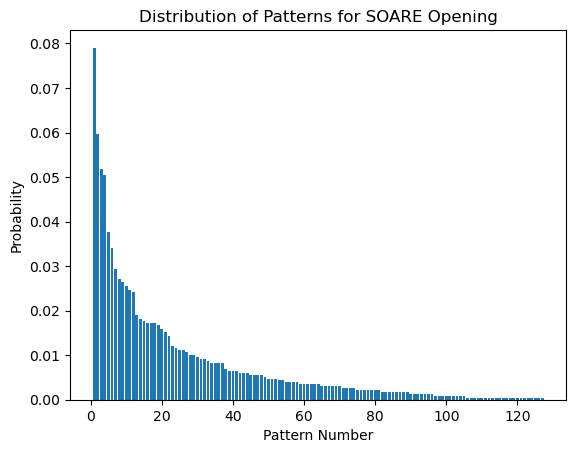

In [21]:
plot_pattern_distribution('soare')

SPEED: 88 possible patterns, 4.37 expected halvings (bits) out of 11.18, 242.6 expected remaining words


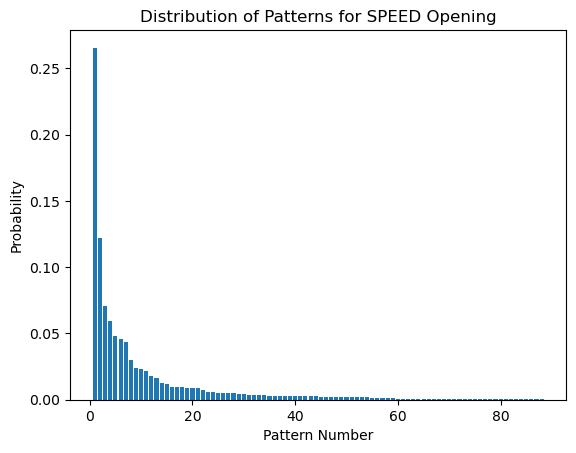

In [22]:
plot_pattern_distribution('speed')

QAJAQ: 18 possible patterns, 1.89 expected halvings (bits) out of 11.18, 925.1 expected remaining words


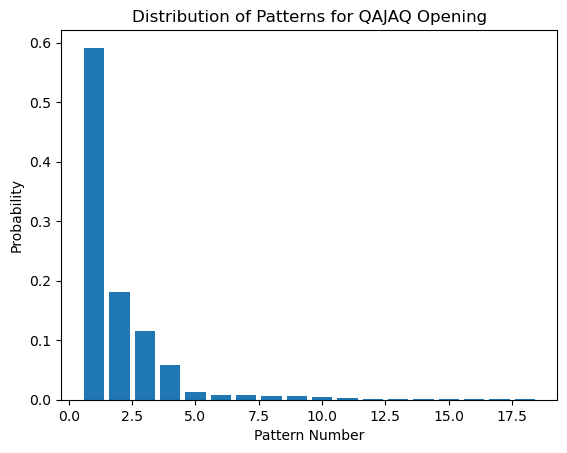

In [23]:
plot_pattern_distribution('qajaq')

The "qajaq" opener is so bad that only a few patterns have a positive probability of appearing. Note that the horizontal axis of the last graph is on a different scale from the previous graphs.

The two scores don't always agree on which guess is best. The cell below lists the top 10 openers under each score.

In [24]:
for score, unit in [('entropy', 'expected halvings (bits)'), ('remaining', 'expected remaining words')]:
    print(f'Top 10 openers by {score}:')
    for word, value in find_best_n_guesses(possible_words, allowed_guesses, n=10, score=score):
        print(f'  {word}: {value:.3f} {unit}')
    print()

Top 10 openers by entropy:
  soare: 5.886 expected halvings (bits)
  roate: 5.883 expected halvings (bits)
  raise: 5.878 expected halvings (bits)
  raile: 5.866 expected halvings (bits)
  reast: 5.865 expected halvings (bits)
  slate: 5.856 expected halvings (bits)
  crate: 5.835 expected halvings (bits)
  salet: 5.835 expected halvings (bits)
  irate: 5.831 expected halvings (bits)
  trace: 5.831 expected halvings (bits)

Top 10 openers by remaining:
  roate: 60.425 expected remaining words
  raise: 61.001 expected remaining words
  raile: 61.331 expected remaining words
  soare: 62.301 expected remaining words
  arise: 63.726 expected remaining words
  irate: 63.779 expected remaining words
  orate: 63.891 expected remaining words
  ariel: 65.288 expected remaining words
  arose: 66.021 expected remaining words
  raine: 67.056 expected remaining words



<!-- BEGIN QUESTION -->

**Written Question 3:** 1. Using the three plots, explain why a flatter pattern distribution is better under both scores. Why is "qajaq" such a bad opener?
2. Which opener minimizes the expected number of remaining words? Which of the two scores would you rather use to pick guesses, and why? There is no single right answer; argue from what each score rewards.

**Solution:**

1. A flatter distribution spreads the probability over many patterns, so every group is small. Both scores reward this. For Score 1, $N \sum_y p_y^2$ is small when no $p_y$ is large (for $m$ patterns it is at least $N/m$, with equality when all $p_y = 1/m$). For Score 2, each outcome contributes $\log_2(1/p_y)$ halvings, which is large when $p_y$ is small. Numbers from the plots:

| Opener | Patterns | Largest group | Halvings (bits) | Expected remaining |
|---|---|---|---|---|
| soare | 127 | 183 words (7.9%) | 5.89 | 62.3 |
| speed | 88 | 615 words (26.6%) | 4.37 | 242.6 |
| qajaq | 18 | 1369 words (59.1%) | 1.89 | 925.1 |

"qajaq" uses rare letters (q, j) plus a repeated q and a, so for 59% of secret words it comes back all gray and eliminates almost nothing. Only 18 patterns are possible at all.

2. "roate" minimizes the expected number of remaining words (60.4, vs. 62.3 for "soare"). The scores largely agree: both top-10 lists share roate, raise, raile, soare and irate, and the differences are small. Either answer is acceptable with a reasonable argument. A typical one in favor of entropy: Score 1 weighs each outcome by the square of its group size, so it is dominated by the few largest groups and nearly ignores how well the guess splits the rest. The number of guesses still needed grows roughly with the *logarithm* of the group size, which is exactly what Score 2 averages. A typical one in favor of Score 1: it measures a concrete, interpretable quantity (words left), and punishes bad worst-case outcomes more heavily.

<!-- END QUESTION -->

## Some Useful Optimizations

Two tweaks make the solver faster and better. First, the opening guess is always made from the same alphabet (all of `possible_words`), so it is always `best_opener`, and there is no need to recompute it every game.

Second, when only a few words remain, it is better to guess one of them than a more informative word that can't be the answer. The next question makes this precise.

<!-- BEGIN QUESTION -->

**Written Question 4:** Let $G$ be the number of guesses we still need to make until we win, including the winning guess. Assume the secret word is uniform over the current alphabet.

1. The alphabet is {"price", "pride"}. Compute $E[G]$ if we first guess "camel" (which tells the two apart), and $E[G]$ if we first guess "price".
2. Now suppose the alphabet has 3 words. Compute $E[G]$ if we first guess (a) a word in the alphabet whose pattern tells the other two apart, (b) a word in the alphabet whose pattern cannot tell the other two apart, and (c) a word outside the alphabet that tells all three apart. In each case, assume we play optimally afterwards.
3. Based on your answers, explain why it makes sense to restrict our guesses to the alphabet when $|\mathcal{A}_t| \leq 3$.

**Solution:**

1. Guessing "camel": it can't be the answer, but it identifies it, so $G = 2$ always and $E[G] = 2$. Guessing "price": we win immediately with probability $1/2$, and otherwise we know the answer is "pride", so $E[G] = \frac{1}{2} \cdot 1 + \frac{1}{2} \cdot 2 = 1.5$.

2. (a) With probability $1/3$ we win on guess 1; otherwise the pattern identifies the answer and we win on guess 2: $E[G] = \frac{1}{3} \cdot 1 + \frac{2}{3} \cdot 2 = \frac{5}{3}$.

   (b) With probability $1/3$ we win on guess 1; otherwise two words remain, and by part 1 the best we can do is $1.5$ more guesses in expectation: $E[G] = \frac{1}{3} \cdot 1 + \frac{2}{3}(1 + 1.5) = 2$.

   (c) The guess can't be the answer but identifies it, so $G = 2$ and $E[G] = 2$.

3. A word outside the alphabet can never be the answer, so it always costs at least 2 guesses: $E[G] \geq 2$. For $|\mathcal{A}_t| \leq 3$, guessing inside the alphabet achieves $E[G] \leq 2$ no matter how well the guess splits the remaining words (1.5 for two words, $\frac{5}{3}$ or 2 for three), so it is never worse and usually strictly better. For larger alphabets this can flip: with 4 words, an outside word that separates all of them gives $E[G] = 2$, while an inside word that can't separate the other three gives $E[G] \geq \frac{1}{4} + \frac{3}{4}(1 + \frac{5}{3}) = 2.25$.

<!-- END QUESTION -->

**Task 5:** Implement `find_best_guess_optimized`, which takes in the current alphabet and returns the next word to guess using the default entropy score:
- If this is the opening guess (the alphabet is all of `possible_words`), return `best_opener` directly.
- If only one word remains, return it.
- If 2 or 3 words remain, return the best guess from within the alphabet, i.e. `find_best_guess(alphabet, alphabet)`.
- Otherwise, return the best guess from all of `allowed_guesses`.

In [25]:
def find_best_guess_optimized(alphabet):
    if len(alphabet) == len(possible_words):
        # if it's the opening guess, we directly output the precomputed opener
        return best_opener
    elif len(alphabet) == 1:
        # if we are certain what the secret word is, directly guess it
        return alphabet[0]
    elif len(alphabet) <= 3:
        # if the alphabet is small, limit our guess to within the alphabet
        return find_best_guess(alphabet, alphabet)
    else:
        # otherwise, search all allowed guesses
        return find_best_guess(alphabet, allowed_guesses)

In [26]:
grader.check("find_best_guess_optimized")

find_best_guess_optimized results: All test cases passed!

## Performance Test

Let's now sample some secret words and watch our solver find the secret word in action! The provided function `create_wordle_game` takes in a secret word and returns a function that plays the role of the game: given a guess, it returns the color pattern.

In [27]:
def create_wordle_game(true_answer):
    def wordle_game(guess):
        # takes in a guess and outputs the pattern
        return compute_pattern(guess, true_answer)

    return wordle_game

**Task 6:** Implement `play_wordle`, which takes in a game created by `create_wordle_game` and plays it until it wins: guess with `find_best_guess_optimized`, then narrow down the alphabet with `filter_alphabet` using the pattern the game returns. It should return the number of guesses used, including the final correct guess. If `print_guesses` is `True`, also print each guess and its pattern.

In [28]:
def play_wordle(wordle_game, print_guesses=False):
    alphabet = possible_words
    num_guesses = 0
    while True:
        num_guesses += 1
        guess = find_best_guess_optimized(alphabet)
        color_pattern = wordle_game(guess)
        if print_guesses:
            print(f'Guess {num_guesses}: {guess}  |  Pattern: {color_pattern}')
        if color_pattern == (2, 2, 2, 2, 2):
            # correct answer!
            break
        alphabet = filter_alphabet(alphabet, guess, color_pattern)
    return num_guesses

In [29]:
for _ in range(10):
    true_answer = random.choice(possible_words)
    print('Secret word:', true_answer)
    wordle_game = create_wordle_game(true_answer)
    play_wordle(wordle_game, print_guesses=True)
    print()

Secret word: howdy
Guess 1: soare  |  Pattern: (0, 2, 0, 0, 0)
Guess 2: culty  |  Pattern: (0, 0, 0, 0, 2)
Guess 3: goody  |  Pattern: (0, 2, 0, 2, 2)
Guess 4: dowdy  |  Pattern: (0, 2, 2, 2, 2)
Guess 5: howdy  |  Pattern: (2, 2, 2, 2, 2)

Secret word: olden
Guess 1: soare  |  Pattern: (0, 1, 0, 0, 1)
Guess 2: lento  |  Pattern: (1, 1, 1, 0, 1)
Guess 3: olden  |  Pattern: (2, 2, 2, 2, 2)

Secret word: boxer
Guess 1: soare  |  Pattern: (0, 2, 0, 1, 1)
Guess 2: rewth  |  Pattern: (1, 1, 0, 0, 0)
Guess 3: black  |  Pattern: (2, 0, 0, 0, 0)
Guess 4: boxer  |  Pattern: (2, 2, 2, 2, 2)

Secret word: flyer
Guess 1: soare  |  Pattern: (0, 0, 0, 1, 1)
Guess 2: direr  |  Pattern: (0, 0, 0, 2, 2)
Guess 3: butyl  |  Pattern: (0, 0, 0, 1, 1)
Guess 4: flyer  |  Pattern: (2, 2, 2, 2, 2)

Secret word: green
Guess 1: soare  |  Pattern: (0, 0, 0, 1, 1)
Guess 2: direr  |  Pattern: (0, 0, 1, 2, 0)
Guess 3: pence  |  Pattern: (0, 1, 1, 0, 1)
Guess 4: green  |  Pattern: (2, 2, 2, 2, 2)

Secret word: heron
G

Let's take a look at the distribution of the number of guesses needed by sampling 300 secret words.

In [30]:
num_guesses = []
num_samples = 300
for true_answer in tqdm(random.sample(possible_words, num_samples)):
    num_guesses.append(play_wordle(create_wordle_game(true_answer)))

100%|██████████| 300/300 [00:09<00:00, 31.86it/s]


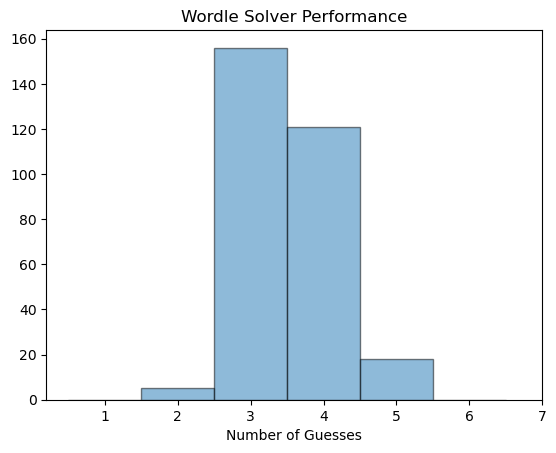

In [31]:
bins = list(range(1, 8))
plt.hist(num_guesses, bins, alpha=0.5, edgecolor='black', align='left')
plt.xlabel('Number of Guesses')
plt.xticks(list(range(1, 8)))
plt.title('Wordle Solver Performance')
plt.show()

If your implementation is correct, your Wordle solver takes fewer guesses on average than American players do.

In [32]:
print(f'Average number of Wordle guesses using entropy: {round(sum(num_guesses)/len(num_guesses), 3)}')
print('Average number of Wordle guesses for Americans: 3.92')

Average number of Wordle guesses using entropy: 3.507
Average number of Wordle guesses for Americans: 3.92


In [33]:
grader.check("play_wordle")

play_wordle results: All test cases passed!

## How Good Is the Solver?

Our solver is deterministic, so its average number of guesses over all 2315 possible secret words is a fixed number $\mu$. Above, we estimated $\mu$ with the sample mean $\bar{G}$ of 300 randomly chosen secret words. How confident can we be that $\mu < 3.92$?

**Task 7:** Implement `confidence_interval`, which takes in a list of samples and returns a tuple `(low, high)`: the approximate confidence interval for the mean given by the Central Limit Theorem,
$$\bar{G} \pm z \frac{s}{\sqrt{n}},$$
where $n$ is the number of samples, $s$ is the sample standard deviation (with $n - 1$ in the denominator, i.e. `np.std(samples, ddof=1)`), and $z$ is chosen so that $P(-z \leq Z \leq z)$ equals `confidence` for $Z \sim \mathcal{N}(0, 1)$. You may find `stats.norm.ppf` helpful.

In [34]:
def confidence_interval(samples, confidence=0.95):
    # Returns (low, high), the CLT confidence interval for the mean of `samples`
    samples = np.asarray(samples, dtype=np.float64)
    z = stats.norm.ppf(0.5 + confidence / 2)
    half_width = z * samples.std(ddof=1) / np.sqrt(len(samples))
    return samples.mean() - half_width, samples.mean() + half_width

In [35]:
grader.check("confidence_interval")

confidence_interval results: All test cases passed!

In [36]:
low, high = confidence_interval(num_guesses, confidence=0.95)
print(f'95% confidence interval for the average number of guesses: ({low:.3f}, {high:.3f})')

95% confidence interval for the average number of guesses: (3.435, 3.579)


<!-- BEGIN QUESTION -->

**Written Question 5:** 1. Report your 95% confidence interval. Can you conclude that the solver beats the 3.92 average of American players?
2. Chebyshev's inequality gives a confidence interval without relying on the CLT. Assuming the standard deviation $\sigma$ of the number of guesses is known, how wide is the 95% interval from Chebyshev's inequality compared to the CLT interval? Plugging in $s$ for $\sigma$, would your conclusion in part 1 change?
3. The 300 secret words were sampled *without* replacement, so the samples are not independent. Why is the CLT interval still reasonable here? What would happen if we sampled all 2315 words?

**Solution:**

Numbers below are from running the notebook top to bottom with the default seed: $\bar{G} = 3.507$, $s \approx 0.636$, $n = 300$.

1. The 95% CLT interval is $3.507 \pm 1.96 \cdot 0.636/\sqrt{300} \approx 3.507 \pm 0.072 = (3.435, 3.579)$. The whole interval is below 3.92, so yes, at the 95% level we can conclude $\mu < 3.92$. (Full credit doesn't require it, but a strong answer notes that 3.92 is itself an estimate, and that human players face a different setup, e.g. they don't know the answer list.)

2. Chebyshev: $P(|\bar{G} - \mu| \geq \epsilon) \leq \frac{\sigma^2}{n \epsilon^2}$. Setting the right side to $0.05$ gives $\epsilon = \frac{\sigma}{\sqrt{0.05\, n}} \approx 4.47 \frac{\sigma}{\sqrt{n}}$, compared with $1.96 \frac{\sigma}{\sqrt{n}}$ for the CLT, so the interval is about $2.28\times$ wider. Plugging in $s$: $3.507 \pm 0.164 = (3.343, 3.671)$, still entirely below 3.92, so the conclusion doesn't change.

3. Because $n = 300$ is small compared to $N = 2315$, the samples are nearly independent: learning one sampled word barely changes the distribution of the next. In fact, sampling without replacement *reduces* the variance of $\bar{G}$ by the factor $\frac{N - n}{N - 1} \approx 0.87$, so the CLT interval is slightly conservative. If we sampled all 2315 words, $\bar{G}$ would equal $\mu$ exactly (3.464), with no randomness left and a zero-width interval.

<!-- END QUESTION -->

## Wordle Bot (Optional)

Finally, let's turn the solver into an assistant for real games! This section is optional and not graded.

Implement the class `WordleBot` below. It keeps track of the words that the secret could still be, suggests guesses, and updates when you tell it which pattern the game showed:
- `suggest()` prints how many words remain (listing them if there are only a few), prints the top `num_suggestions` guesses with their scores, and returns the best one.
- `observe(word, pattern)` narrows down the alphabet using the word you actually guessed and the pattern the game showed, then calls and returns `suggest()`.
- `restart()` resets the bot for a new game.

Some ideas for extending the bot:
- Show each suggestion's score under both `'entropy'` and `'remaining'`.
- **Uncommon answers.** The NYT has occasionally picked answers that are valid guesses but aren't in `possible_words`, like "pshaw". If the bot's only candidates are `possible_words`, it runs out of words in that case. Keep a second candidate set drawn from `allowed_guesses` and fall back to it when no word from `possible_words` fits. (`pattern_table`, `filter_alphabet`, and the solver functions work for any 5-letter words; they're just slower for words outside `possible_words`.)

In [37]:
class WordleBot:
    # The bot tracks TWO candidate sets:
    #   - self.candidates: consistent words from possible_words (by far the
    #     most likely answers)
    #   - self.extended: consistent words from the full allowed_guesses list,
    #     used as a fallback when no word from possible_words fits anymore
    def __init__(self, num_suggestions=10, max_listed=50):
        self.num_suggestions = num_suggestions
        self.max_listed = max_listed
        self.restart()

    @property
    def alphabet(self):
        return self.candidates if self.candidates else self.extended

    def suggest(self):
        alphabet = self.alphabet
        if len(alphabet) == 0:
            print('No valid words remain - a pattern was probably entered '
                  'incorrectly. Call restart() to reset.')
            return None
        if not self.candidates:
            print('None of the common answer words fit anymore - searching the full word list.')
        if len(alphabet) == 1:
            print('The secret word is:', alphabet[0])
            return alphabet[0]

        if len(alphabet) <= self.max_listed:
            print(f'{len(alphabet)} possible word(s) remaining:', ' '.join(alphabet))
        else:
            print(f'{len(alphabet)} possible words remaining')

        possible = set(alphabet)
        guesses = alphabet if len(alphabet) <= 3 else allowed_guesses
        ranked = find_best_n_guesses(alphabet, guesses, n=self.num_suggestions)
        print('Top suggested guesses:')
        for word, bits in ranked:
            tag = '  <- possible answer' if word in possible else ''
            print(f'  {word}: {bits:.3f} bits{tag}')
        return ranked[0][0]

    def observe(self, word, pattern):
        assert len(word) == len(pattern) == 5
        self.candidates = filter_alphabet(self.candidates, word, pattern)
        self.extended = filter_alphabet(self.extended, word, pattern)
        return self.suggest()

    def restart(self):
        self.candidates = list(possible_words)
        self.extended = list(allowed_guesses)

Try your bot on an example game. The secret word here is "whine".

In [38]:
bot = WordleBot()
bot.suggest()

2315 possible words remaining
Top suggested guesses:
  soare: 5.886 bits
  roate: 5.883 bits
  raise: 5.878 bits  <- possible answer
  raile: 5.866 bits
  reast: 5.865 bits
  slate: 5.856 bits  <- possible answer
  crate: 5.835 bits  <- possible answer
  salet: 5.835 bits
  irate: 5.831 bits  <- possible answer
  trace: 5.831 bits  <- possible answer


'soare'

In [39]:
bot.observe('soare', (0, 0, 0, 0, 2))

79 possible words remaining
Top suggested guesses:
  guilt: 5.068 bits
  culti: 4.914 bits
  guild: 4.896 bits
  lucid: 4.885 bits
  tunic: 4.872 bits
  build: 4.869 bits
  built: 4.847 bits
  glint: 4.841 bits
  cunit: 4.831 bits
  ludic: 4.817 bits


'guilt'

In [40]:
bot.observe('guilt', (0, 0, 2, 0, 0))

4 possible word(s) remaining: chide chime knife whine
Top suggested guesses:
  chide: 2.000 bits  <- possible answer
  chime: 2.000 bits  <- possible answer
  aband: 2.000 bits
  ached: 2.000 bits
  adhan: 2.000 bits
  adown: 2.000 bits
  adunc: 2.000 bits
  ahind: 2.000 bits
  aland: 2.000 bits
  amend: 2.000 bits


'chide'

In [41]:
bot.observe('chide', (0, 2, 2, 0, 2))

The secret word is: whine


'whine'

In [42]:
bot.observe('whine', (2, 2, 2, 2, 2))

The secret word is: whine


'whine'

Now an uncommon answer: the secret word here is "pshaw", which is not in `possible_words`. Your bot will only handle this game if you implemented the fallback extension.

In [43]:
bot.restart()

In [44]:
bot.observe('soare', (1, 0, 1, 0, 0))

23 possible word(s) remaining: abyss amiss angst assay basal basic basil basin basis daisy gassy hasty nasal nasty palsy pansy pasta pasty patsy tasty usual vista waist
Top suggested guesses:
  linty: 3.936 bits
  unity: 3.903 bits
  patin: 3.849 bits
  tiyns: 3.849 bits
  lysis: 3.828 bits
  panty: 3.828 bits
  minty: 3.816 bits
  nyssa: 3.816 bits
  pissy: 3.816 bits
  tiyin: 3.816 bits


'linty'

In [45]:
bot.observe('linty', (0, 0, 0, 0, 0))

None of the common answer words fit anymore - searching the full word list.
152 possible words remaining
Top suggested guesses:
  chump: 4.411 bits
  bumph: 4.338 bits
  mucks: 4.293 bits
  pucks: 4.272 bits
  mahua: 4.259 bits
  hakam: 4.214 bits
  pucka: 4.196 bits
  mapau: 4.195 bits
  whump: 4.184 bits
  kacha: 4.174 bits


'chump'

In [46]:
bot.observe('chump', (0, 1, 0, 0, 1))

None of the common answer words fit anymore - searching the full word list.
4 possible word(s) remaining: hasps kaphs pasha pshaw
Top suggested guesses:
  hasps: 2.000 bits  <- possible answer
  kaphs: 2.000 bits  <- possible answer
  pasha: 2.000 bits  <- possible answer
  akkas: 2.000 bits
  alaps: 2.000 bits
  amahs: 2.000 bits
  amass: 2.000 bits
  ankhs: 2.000 bits
  ansae: 2.000 bits
  apeak: 2.000 bits


'hasps'

In [47]:
bot.observe('hasps', (1, 1, 1, 1, 0))

None of the common answer words fit anymore - searching the full word list.
The secret word is: pshaw


'pshaw'

In [48]:
bot.observe('pshaw', (2, 2, 2, 2, 2))

None of the common answer words fit anymore - searching the full word list.
The secret word is: pshaw


'pshaw'